<a href="https://colab.research.google.com/github/Pascual-Soriano/Redes-Neuronales/blob/main/Reconocimiento_facial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Instalar la librería de Kaggle
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pascualsoriano","key":"5f5e87e67d4a0d3f948620ae77ef84f3"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [10]:
ls -ltr ~/.kaggle

total 4
-rw------- 1 root root 70 Mar 26 16:29 kaggle.json


In [9]:
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# Descargar el dataset (esto lo baja comprimido al almacenamiento de Colab)
!kaggle datasets download -d jessicali9530/celeba-dataset

# Descomprimir el archivo
!unzip -q celeba-dataset.zip -d celeba_data

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:16<00:00, 88.8MB/s]



In [12]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.pyplot
import random

print(tf.__version__)
import os
import cv2
import pandas as pd
#from tensorflow.keras import layers, models

2.19.0


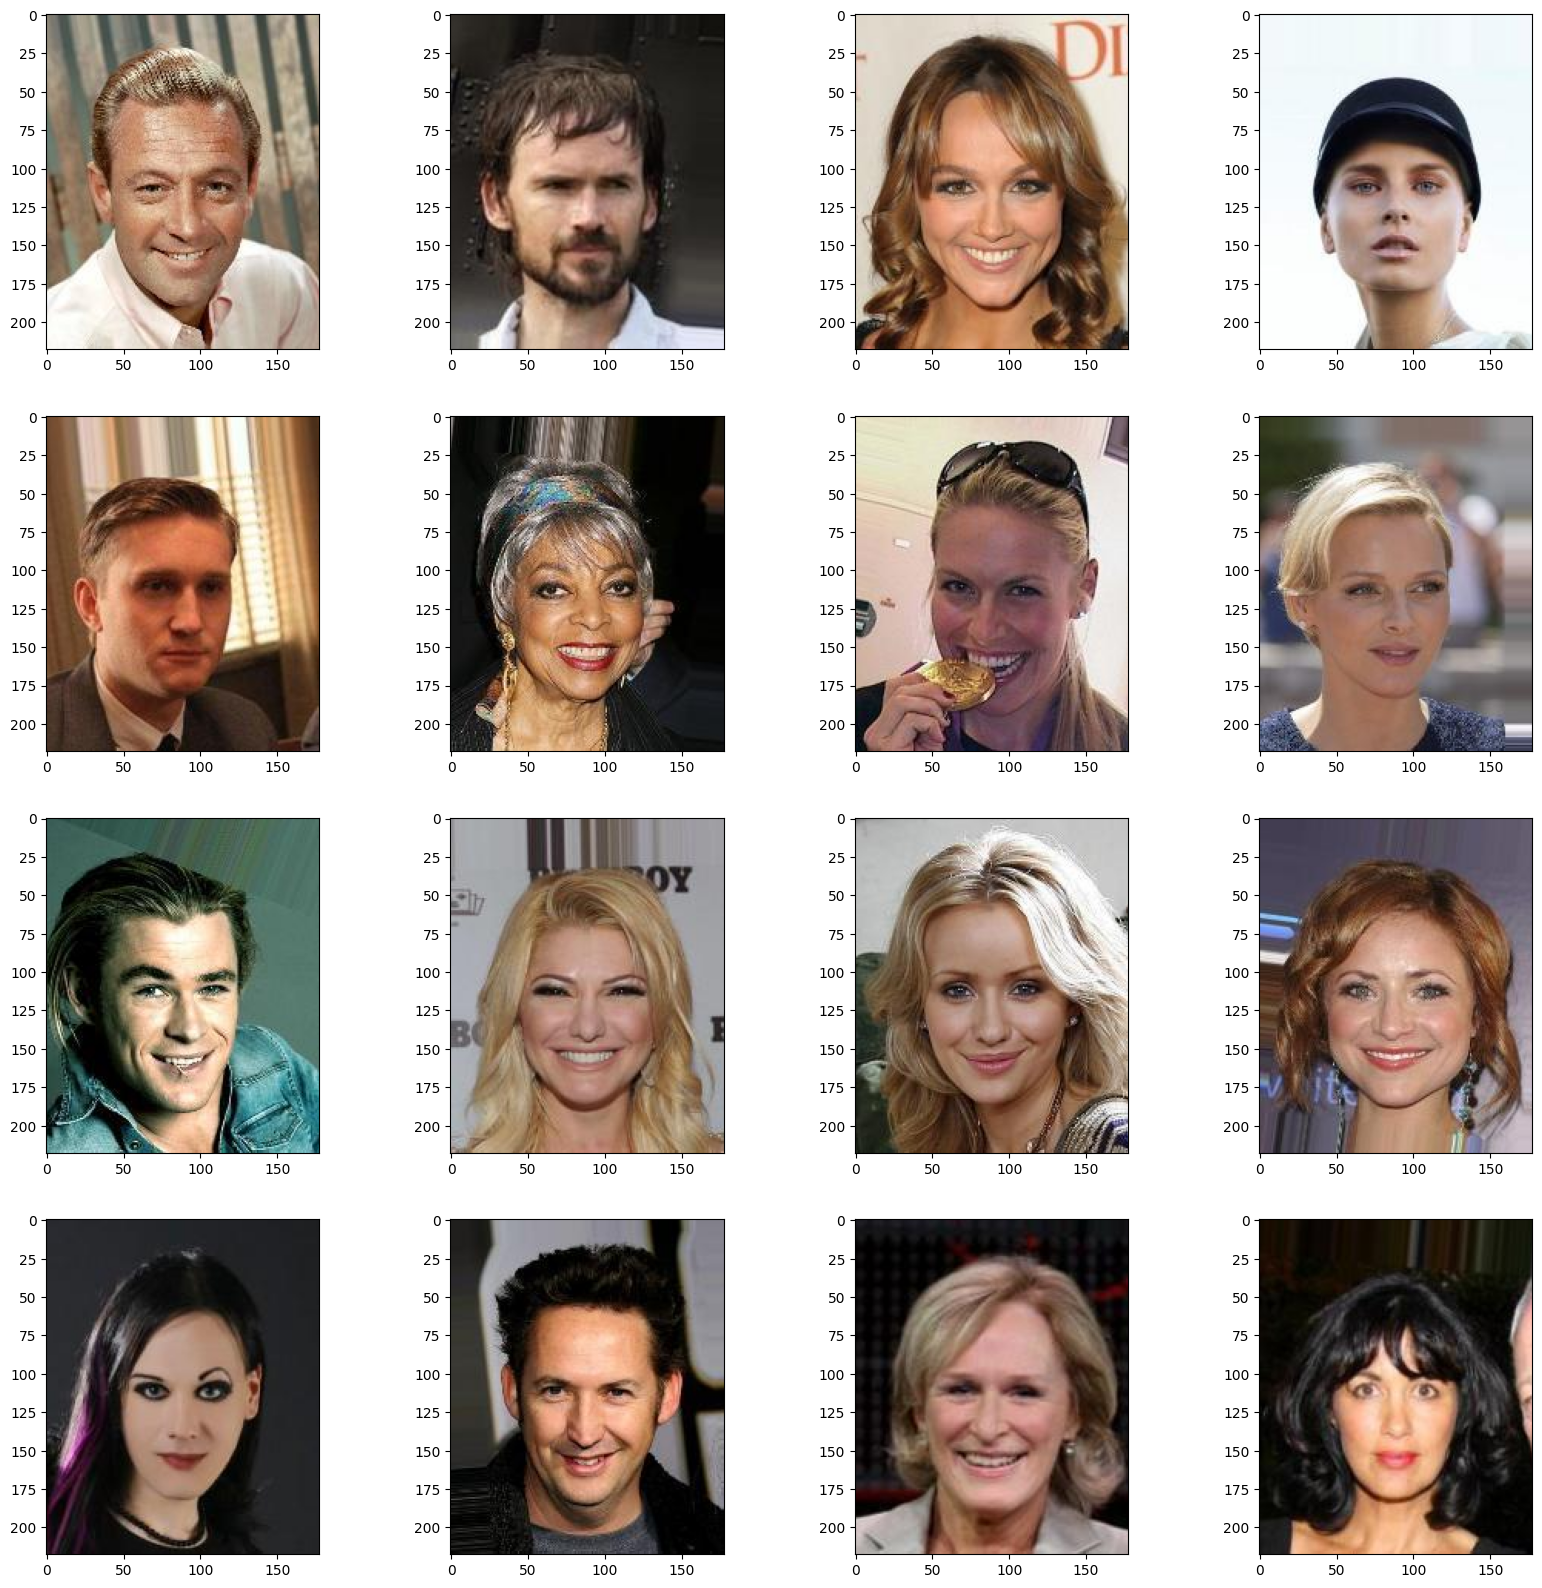

In [10]:
images = 'celeba_data/img_align_celeba/img_align_celeba'
samples = random.sample(os.listdir(images),16)

plt.figure(figsize=(20, 20))
for i, img_name in enumerate(samples):
  img = cv2.resize(cv2.imread(os.path.join(images, img_name)), (1, 1))
  img = cv2.imread(os.path.join(images, img_name))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.subplot(4, 4, i+1)
  plt.imshow(img)
  plt.axis('on')
plt.show()

In [13]:
df = pd.read_csv("/content/celeba_data/list_attr_celeba.csv")

print(df)

          image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  \
0       000001.jpg                -1                1           1   
1       000002.jpg                -1               -1          -1   
2       000003.jpg                -1               -1          -1   
3       000004.jpg                -1               -1           1   
4       000005.jpg                -1                1           1   
...            ...               ...              ...         ...   
202594  202595.jpg                -1               -1           1   
202595  202596.jpg                -1               -1          -1   
202596  202597.jpg                -1               -1          -1   
202597  202598.jpg                -1                1           1   
202598  202599.jpg                -1                1           1   

        Bags_Under_Eyes  Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  \
0                    -1    -1     -1        -1        -1          -1  ...   
1                

In [14]:
# Cambiar etiquetas de -1 a 0 (Keras prefiere 0 y 1)
df.replace(-1, 0, inplace=True)

print(df.columns)

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young'],
      dtype='object')


In [15]:
df_subset = df.iloc[:20000]

print(df_subset)

         image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  \
0      000001.jpg                 0                1           1   
1      000002.jpg                 0                0           0   
2      000003.jpg                 0                0           0   
3      000004.jpg                 0                0           1   
4      000005.jpg                 0                1           1   
...           ...               ...              ...         ...   
19995  019996.jpg                 0                1           1   
19996  019997.jpg                 0                0           0   
19997  019998.jpg                 0                1           1   
19998  019999.jpg                 0                1           1   
19999  020000.jpg                 0                0           1   

       Bags_Under_Eyes  Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  \
0                    0     0      0         0         0           0  ...   
1                    1     0   

In [16]:
hair = ['Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Gray_Hair',
    'Bald', 'Straight_Hair', 'Wavy_Hair', 'Bangs']

# Creamos un subconjunto solo con el ID de la imagen y esos atributos
df_hair = df_subset[['image_id'] + hair]

print(df_hair)


         image_id  Black_Hair  Blond_Hair  Brown_Hair  Gray_Hair  Bald  \
0      000001.jpg           0           0           1          0     0   
1      000002.jpg           0           0           1          0     0   
2      000003.jpg           0           0           0          0     0   
3      000004.jpg           0           0           0          0     0   
4      000005.jpg           0           0           0          0     0   
...           ...         ...         ...         ...        ...   ...   
19995  019996.jpg           0           0           1          0     0   
19996  019997.jpg           0           0           0          0     0   
19997  019998.jpg           0           1           0          0     0   
19998  019999.jpg           0           0           0          0     0   
19999  020000.jpg           0           0           0          0     0   

       Straight_Hair  Wavy_Hair  Bangs  
0                  1          0      0  
1                  0         

In [27]:
from tensorflow.keras import datasets, layers, models

# 1. Definición de la arquitectura (Paso 1 del PDF)
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu')) # Cambiado a relu para mejor flujo de gradiente
model.add(layers.Dense(8, activation='sigmoid')) # 8 neuronas para atributos de pelo

# 2. Compilación del modelo
# Usamos binary_crossentropy porque un rostro puede tener varios tipos de pelo a la vez
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,552 (736.53 KB)

 Trainable params: 188,552 (736.53 KB)

 Non-trainable params: 0 (0.00 B)

In [150]:
# 3. Entrenamiento (Simulado)

#model.fit(train_generator, epochs=10, validation_data=val_generator)

# 4. GUARDAR EL MODELO (Crucial para el Transfer Learning posterior)
model.save('my.model.keras')

In [162]:
# CARGAR EL MODELO PRE-ENTRENADO
pre_trained_model = tf.keras.models.load_model('my.model.keras')

# CREAR EL NUEVO MODELO
model_nuevo = models.Sequential()

# Añadimos las capas convolucionales del modelo anterior.
# Vamos a reutilizar esas 5 capas que ya saben extraer características faciales.
for i in range(5):
    model_nuevo.add(pre_trained_model.layers[i])

# CONGELAR CAPAS
for layer in model_nuevo.layers:
    layer.trainable = False

# AGREGAR CAPAS NUEVAS

model_nuevo.add(layers.Flatten())
model_nuevo.add(layers.Dense(128, activation='relu'))
model_nuevo.add(layers.Dropout(0.5)) # Apaga el 50% de las neuronas en cada paso
model_nuevo.add(layers.Dense(1, activation='sigmoid'))
# 5. COMPILAR EL NUEVO MODELO
model_nuevo.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

model_nuevo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 56,320 (220.00 KB)

In [163]:
import pandas as pd

# Unimos ambos DataFrames
df_entrenamiento_final = pd.concat([df_otros, df_yo], ignore_index=True)

# Mezclamos los datos
df_entrenamiento_final = df_entrenamiento_final.sample(frac=1).reset_index(drop=True)

In [164]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Re-create df_otros with full filepaths
base_dir_celeba = 'celeba_data/img_align_celeba/img_align_celeba'
df_otros_with_paths = df_otros.copy()
df_otros_with_paths['filepath'] = df_otros_with_paths['image_id'].apply(lambda x: os.path.join(base_dir_celeba, x))

# Re-create df_yo with full filepaths
base_dir_mis_fotos = '/content/drive/MyDrive/Datasets/mis_fotos'
df_yo_with_paths = df_yo.copy()
df_yo_with_paths['filepath'] = df_yo_with_paths['image_id'].apply(lambda x: os.path.join(base_dir_mis_fotos, x))

# Concatenate the dataframes with filepaths to create the final dataset for training
df_final_with_paths = pd.concat([df_otros_with_paths[['filepath', 'label']], df_yo_with_paths[['filepath', 'label']]], ignore_index=True)

# Shuffle the combined dataframe for randomness during training
df_final_with_paths = df_final_with_paths.sample(frac=1, random_state=42).reset_index(drop=True)

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Create a single generator for training using the combined dataframe with full paths
train_generator = datagen.flow_from_dataframe(
    dataframe=df_final_with_paths,
    x_col='filepath', # Use the 'filepath' column for image paths
    y_col='label',
    target_size=(32, 32),
    class_mode='binary',
    batch_size=32,
    subset='training', # Specify for training subset
    seed=42)

# Create a single generator for validation using the combined dataframe with full paths
validation_generator = datagen.flow_from_dataframe(
    dataframe=df_final_with_paths,
    x_col='filepath',
    y_col='label',
    target_size=(32, 32),
    class_mode='binary',
    batch_size=32,
    subset='validation', # Specify for validation subset
    seed=42)

print("Training generator created successfully.")
print("Validation generator created successfully.")

Found 24 validated image filenames belonging to 2 classes.
Found 5 validated image filenames belonging to 2 classes.
Training generator created successfully.
Validation generator created successfully.


In [165]:
# 1. Entrenamiento inicial (solo las capas nuevas)
history = model_nuevo.fit(
    train_generator,
    epochs=25,
    validation_data=validation_generator
)

# 2. Refinamiento (opcional, según el punto 2.c de tu PDF)
# Descongelamos las últimas capas para un ajuste más preciso
for layer in model_nuevo.layers[-3:]: # Descongelamos las últimas 3 capas
    layer.trainable = False

# Re-compilamos con un learning rate muy pequeño
model_nuevo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Unas pocas épocas más para ajustar los detalles de tu rostro
model_nuevo.fit(train_generator, epochs=5, validation_data=validation_generator)

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4167 - loss: 0.7073 - val_accuracy: 0.4000 - val_loss: 0.6882
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step - accuracy: 0.6250 - loss: 0.6778 - val_accuracy: 1.0000 - val_loss: 0.6810
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.6250 - loss: 0.6642 - val_accuracy: 1.0000 - val_loss: 0.6753
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.7500 - loss: 0.6447 - val_accuracy: 0.8000 - val_loss: 0.6695
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step - accuracy: 0.8333 - loss: 0.6462 - val_accuracy: 0.6000 - val_loss: 0.6636
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.5833 - loss: 0.6449 - val_accuracy: 0.6000 - val_loss: 0.6582
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8333 - loss: 0.6342 - val_accuracy: 0.6000 - val_loss: 0.6532
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step - accuracy: 0.7917 - loss: 0.6264 - val_accuracy: 0.6000 - val_loss: 0.

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8333 - loss: 0.4468 - val_accuracy: 0.6000 - val_loss: 0.5683
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.7917 - loss: 0.4574 - val_accuracy: 0.6000 - val_loss: 0.5683
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9167 - loss: 0.4276 - val_accuracy: 0.6000 - val_loss: 0.5683
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.8333 - loss: 0.4506 - val_accuracy: 0.6000 - val_loss: 0.5683
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.8333 - loss: 0.4629 - val_accuracy: 0.6000 - val_loss: 0.5683


In [166]:
# Entrenamos el modelo
history = model_nuevo.fit(
    train_generator,
    epochs=15, # 10 a 15 épocas suelen ser suficientes para transfer learning
    validation_data=validation_generator
)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step - accuracy: 0.9167 - loss: 0.4267 - val_accuracy: 0.6000 - val_loss: 0.5683
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.8750 - loss: 0.4663 - val_accuracy: 0.6000 - val_loss: 0.5683
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.7917 - loss: 0.4424 - val_accuracy: 0.6000 - val_loss: 0.5683
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.8333 - loss: 0.4596 - val_accuracy: 0.6000 - val_loss: 0.5683
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.8750 - loss: 0.4475 - val_accuracy: 0.6000 - val_loss: 0.5683
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8333 - loss: 0.4274 - val_accuracy: 0.6000 - val_loss: 0.5683
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.7917 - loss: 0.4596 - val_accuracy: 0.6000 - val_loss: 0.5683
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8750 - loss: 0.4405 - val_accuracy: 0.6000 - val_loss:

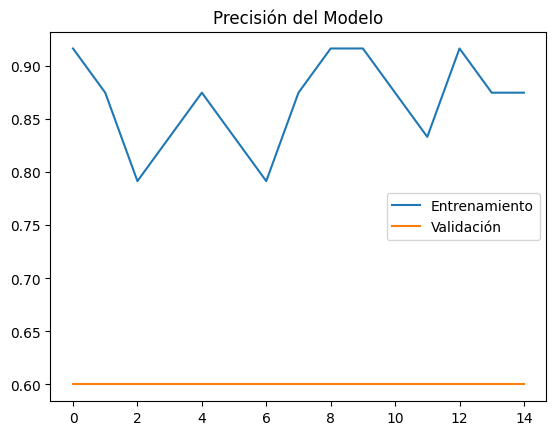

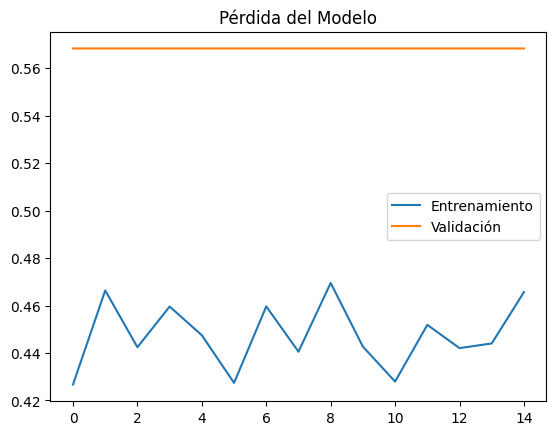

In [167]:
import matplotlib.pyplot as plt

# Graficar Precisión
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo')
plt.legend()
plt.show()

# Graficar Pérdida
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo')
plt.legend()
plt.show()

In [168]:
import numpy as np
from tensorflow.keras.preprocessing import image

def clasificar_rostro(ruta_imagen):
    img = image.load_img(ruta_imagen, target_size=(32, 32))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediccion = model_nuevo.predict(img_array)

    if prediccion[0] > 0.5:
        print(f"Resultado: ¡ERES TÚ! (Confianza: {prediccion[0][0]*100:.2f}%)")
    else:
        print(f"Resultado: NO RECONOCIDO (Confianza: {(1-prediccion[0][0])*100:.2f}%)")

# Prueba con una foto de tu Drive o local
clasificar_rostro('/content/drive/MyDrive/Datasets/imagen_prueba_mia/WhatsApp Image 2026-03-27 at 21.27.55.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Resultado: ¡ERES TÚ! (Confianza: 55.69%)


In [169]:
def clasificar_rostro(ruta_imagen):
    img = image.load_img(ruta_imagen, target_size=(32, 32))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediccion = model_nuevo.predict(img_array)

    if prediccion[0] > 0.5:
        print(f"Resultado: ¡ERES TÚ! (Confianza: {prediccion[0][0]*100:.2f}%)")
    else:
        print(f"Resultado: NO RECONOCIDO (Confianza: {(1-prediccion[0][0])*100:.2f}%)")

# Prueba con una foto de tu Drive o local
clasificar_rostro("/content/drive/MyDrive/Datasets/imagen_prueba_no_mía/WhatsApp Image 2026-03-27 at 22.50.46.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Resultado: ¡ERES TÚ! (Confianza: 52.96%)
